# P1 · Assemble sequences and batches

Unit 0 foundations for the current Tiny Transformer and the later Phyll course. Basic Python variables, loops and functions are assumed.

Download and open this notebook in Jupyter, or choose **File → Upload notebook** in Google Colab. All examples and the required helper code are included. No account key, private repository, GPU or dataset download is needed.

Examples are **illustrative**, executed with Python and PyTorch. Newly constructed model weights are explicitly untrained. Run from a fresh kernel in order. Each exercise can run before you fill it in; open its folded solution afterward.

The `show` helper prints named intermediate results. It is course code, not a built-in Python or PyTorch function.

In [1]:
import sys, math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
torch.set_num_threads(1)
torch.manual_seed(7)
print("Python", sys.version.split()[0], "· PyTorch", torch.__version__, "· CPU")
print("Reference environment: Python 3.12 / PyTorch 2.10. Run with Colab's installed PyTorch or the course requirements.txt.")


Python 3.12.3 · PyTorch 2.10.0+cpu · CPU
Reference environment: Python 3.12 / PyTorch 2.10. Run with Colab's installed PyTorch or the course requirements.txt.


Publication destination: the [public course labs repository](https://github.com/gkiri/tiny_repo). This notebook includes its own examples and can run before that mirror is published.

In [2]:
#@title Display helper: print and draw executed values { display-mode: "form" }
"""Small display helper embedded verbatim in independent notebooks; traces record real executions."""
import json
import math

FRAMES = []


def plain(value):
    if hasattr(value, "detach"):
        return plain(value.detach().cpu().tolist())
    if isinstance(value, dict):
        return {str(k): plain(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [plain(v) for v in value]
    if isinstance(value, float) and not math.isfinite(value):
        return str(value)
    if value is None or isinstance(value, (str, int, float, bool)):
        return value
    return str(value)


def show(label, value):
    """Print and snapshot an intermediate. This helper is course code, not a PyTorch API."""
    frame = {"label": label, "value": plain(value)}
    if hasattr(value, "shape"):
        frame.update(shape=list(value.shape), dtype=str(value.dtype), device=str(value.device))
    FRAMES.append(frame)
    print(label + ":", json.dumps(frame["value"], ensure_ascii=False))
    if "shape" in frame:
        print("  shape", frame["shape"], "·", frame["dtype"], "·", frame["device"])


def draw_trace():
    """A portable SVG trace diagram; requires only the notebook's existing IPython display."""
    import html
    from IPython.display import SVG, display
    height = 82 * len(FRAMES) + 12
    parts = [f'<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 720 {height}" role="img" aria-label="Executed intermediate values">']
    for i, frame in enumerate(FRAMES):
        y = 8 + 82*i
        value = json.dumps(frame["value"], ensure_ascii=False)
        if len(value) > 91:
            value = value[:88] + "…"
        parts += [f'<rect x="4" y="{y}" width="708" height="68" rx="10" fill="#f4f8ef" stroke="#779861"/>',
                  f'<text x="20" y="{y+25}" font-size="15" font-family="sans-serif" fill="#31524b">{i+1}. {html.escape(frame["label"])}</text>',
                  f'<text x="20" y="{y+48}" font-size="12" font-family="monospace" fill="#252a33">{html.escape(value)}</text>']
        if i + 1 < len(FRAMES):
            parts.append(f'<path d="M360 {y+68} v14" stroke="#7042a6" stroke-width="2"/>')
    display(SVG("".join(parts) + "</svg>"))

## P1.4 · Assemble sequences and batches

Stack adds a batch axis; cat extends an existing axis. Input and target windows must move together.

**Prerequisites:** Select the values you mean

**Predict:** Which operation adds a new batch axis?

**Mental model:** A batch contains several examples processed together. For next-character training, every example is a context window with an equally long sequence of shifted targets.

### Why this operation exists

A batch contains several examples processed together. For next-character training, every example is a context window with an equally long sequence of shifted targets.

Stack introduces a new axis around equal-shaped tensors. It turns several time sequences into a batch of time sequences.

Cat extends an axis that already exists. Generation uses it to attach a new token to the time axis while preserving the batch axis.

These operations are not interchangeable, even when they happen to produce the same number of total elements. Axis meaning determines the right choice.

Inspect the original stream and the chosen starts. This makes target alignment a visible property rather than a hidden assumption.

### Follow the values

The source stream contains IDs zero through seven. Choose starts zero and one for two windows of length three.

The windows contain zero, one, two and one, two, three. They overlap in source positions, but remain two distinct examples.

Stack creates the batch axis, giving shape two by three. The first axis selects the example; the second selects time within that example.

Build targets with each start shifted by one. The target batch has the same shape and a different meaning at every aligned position.

Append each final target to its input sequence using cat along time. The resulting two-by-four tensor reconstructs the four source positions needed by each training pair.

In [3]:
FRAMES.clear()
change = 0
torch.manual_seed(7)
stream = torch.arange(8)
starts = [1, 2] if change else [0, 1]
show("Source positions", stream)
windows = [stream[i:i+3] for i in starts]
show("Separate windows", torch.stack(windows))
x = torch.stack(windows, dim=0)
show("Batch [B,T]", x)
y = torch.stack([stream[i+1:i+4] for i in starts])
show("Targets [B,T]", y)
show("Concatenate along time", torch.cat([x, y[:, -1:]], dim=1))
assert x.shape == y.shape == (2, 3)

Source positions: [0, 1, 2, 3, 4, 5, 6, 7]
  shape [8] · torch.int64 · cpu
Separate windows: [[0, 1, 2], [1, 2, 3]]
  shape [2, 3] · torch.int64 · cpu
Batch [B,T]: [[0, 1, 2], [1, 2, 3]]
  shape [2, 3] · torch.int64 · cpu
Targets [B,T]: [[1, 2, 3], [2, 3, 4]]
  shape [2, 3] · torch.int64 · cpu
Concatenate along time: [[0, 1, 2, 3], [1, 2, 3, 4]]
  shape [2, 4] · torch.int64 · cpu


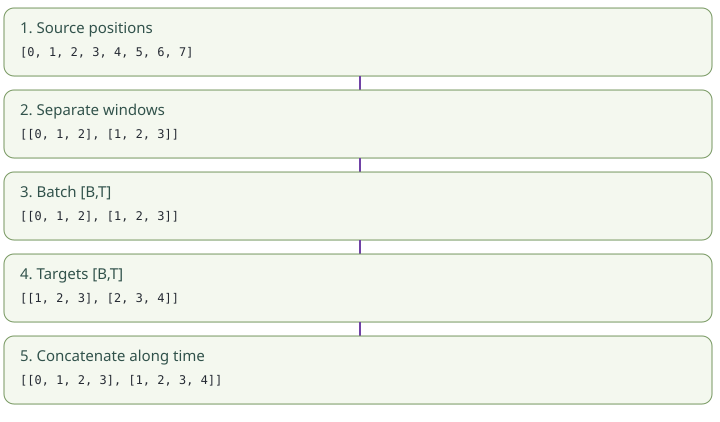

In [4]:
draw_trace()

### See the calculation

The plot uses the tensors just calculated above. Values are rounded for display.

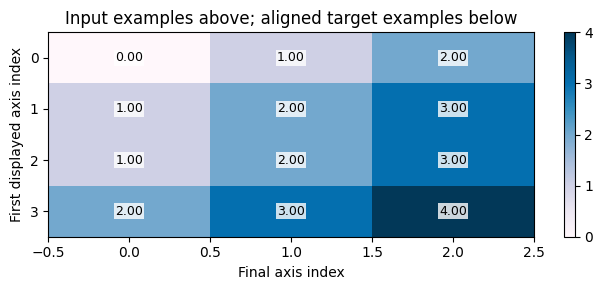

In [5]:
image = (torch.cat([x,y], dim=0).float()).detach().cpu().numpy()
fig, ax = plt.subplots(figsize=(7,3))
plot = ax.imshow(image, cmap="PuBu", aspect="auto")
for row in range(image.shape[0]):
    for col in range(image.shape[1]):
        ax.text(col,row,f"{image[row,col]:.2f}",ha="center",va="center",color="black",fontsize=9,
                bbox={"facecolor":"white","alpha":.8,"edgecolor":"none","pad":1})
ax.set_title('Input examples above; aligned target examples below'); ax.set_xlabel("Final axis index"); ax.set_ylabel("First displayed axis index")
fig.colorbar(plot,ax=ax); plt.tight_layout(); plt.show()

### Read the implementation

The comprehension slices the stream once per start. Stack requires the windows to have matching shapes before it can introduce a batch axis.

A short slice at the end of a stream can therefore break batch construction. Validate that every start leaves room for its final target.

Cat requires all axes other than the chosen concatenation axis to match. Keeping a one-position slice makes the appended target two-dimensional.

Split divides an existing axis into pieces; chunk requests a number of chunks. Check the resulting sizes instead of assuming every requested division is exact.

Dataset and DataLoader offer another way to organize examples. The notebook shows that alternative, while the actual tiny training recipe samples windows directly.

### Change one thing

**Move both starts forward**. Predict which outputs change before running this second case. It executes the same code with `change = 1`.

In [6]:
FRAMES.clear()
change = 1
torch.manual_seed(7)
stream = torch.arange(8)
starts = [1, 2] if change else [0, 1]
show("Source positions", stream)
windows = [stream[i:i+3] for i in starts]
show("Separate windows", torch.stack(windows))
x = torch.stack(windows, dim=0)
show("Batch [B,T]", x)
y = torch.stack([stream[i+1:i+4] for i in starts])
show("Targets [B,T]", y)
show("Concatenate along time", torch.cat([x, y[:, -1:]], dim=1))
assert x.shape == y.shape == (2, 3)

Source positions: [0, 1, 2, 3, 4, 5, 6, 7]
  shape [8] · torch.int64 · cpu
Separate windows: [[1, 2, 3], [2, 3, 4]]
  shape [2, 3] · torch.int64 · cpu
Batch [B,T]: [[1, 2, 3], [2, 3, 4]]
  shape [2, 3] · torch.int64 · cpu
Targets [B,T]: [[2, 3, 4], [3, 4, 5]]
  shape [2, 3] · torch.int64 · cpu
Concatenate along time: [[1, 2, 3, 4], [2, 3, 4, 5]]
  shape [2, 4] · torch.int64 · cpu


### A useful distinction

Stack creates a new axis. Cat changes the length of an existing one.

In [7]:
from torch.utils.data import TensorDataset, DataLoader
dataset = TensorDataset(x, y)
xb, yb = next(iter(DataLoader(dataset, batch_size=2, shuffle=False)))
assert torch.equal(xb, x) and torch.equal(yb, y)
print("DataLoader batches examples; it must preserve each input/target pair.")
print("split:", [tuple(t.shape) for t in x.split(2, dim=1)])

DataLoader batches examples; it must preserve each input/target pair.
split: [(2, 2), (2, 1)]


### ✋ Your turn

Stack tensors [1,2] and [3,4] as two examples; put the resulting nested list in answer.

In [8]:
answer = None  # TODO: replace with your calculation

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == [[1,2],[3,4]], 'Stack creates a new axis. Cat changes the length of an existing one.'
    print("✓ right:", answer)

Your turn: fill in `answer` above, then run this cell again.


In [9]:
#@title Show a solution { display-mode: "form" }
answer = torch.stack([torch.tensor([1,2]), torch.tensor([3,4])]).tolist()

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == [[1,2],[3,4]], 'Stack creates a new axis. Cat changes the length of an existing one.'
    print("✓ right:", answer)

✓ right: [[1, 2], [3, 4]]


### Reconnect to the transformer

Our training loop draws starts from an encoded stream and stacks their windows. The batch axis controls how many examples contribute to a step.

Context length controls the number of time positions in each example. Increasing batch size and increasing context length change different axes and different costs.

Padding is needed when combining unequal lengths by a chosen batching policy. The fixed-length character sampler avoids that particular requirement.

Phyll's data pipeline introduces special tokens and padding masks. The meaning of stack, cat and the next-target shift remains the same.

Next, reorganize values within a tensor while tracking which original coordinate each value came from.

```python
x = torch.stack([data[i:i+context] for i in starts])
y = torch.stack([data[i+1:i+context+1] for i in starts])
```

The excerpt illustrates the corresponding operation. Run the complete chapter example above; excerpts can depend on model context.

**Recall:** Which operation adds a new batch axis?

<details><summary>Check your explanation</summary>

stack. Stack creates a new axis. Cat changes the length of an existing one.

</details>